# Caso de Estudio: Active Learning vs. Semi-Supervised Learning



[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/casos_de_estudio/CE01_optimizacion_presupuesto_etiquetado.ipynb)



## Objetivos del Caso de Estudio


- **Perspectiva de Negocio:** Resolver el problema del "Presupuesto de Etiquetado". Maximizar el rendimiento de un modelo predictivo gastando la menor cantidad de dinero posible en anotación humana.
- **Perspectiva de Ingeniería:** Preprocesar un dataset real evitando fugas de datos (*Data Leakage*) y contrastar tres estrategias de MLOps: Muestreo Aleatorio (*Baseline*), Aprendizaje Semi-Supervisado (SSL) y Aprendizaje Activo (*Active Learning*).
- **Implementación:** Programar un bucle de *Uncertainty Sampling* (Muestreo por Incertidumbre) desde cero utilizando las probabilidades cruzadas de Scikit-Learn.



## Prerrequisitos


- Comprensión de los supuestos del Aprendizaje Semi-Supervisado.
- Haber completado: [Aprendizaje Semi-Supervisado: Explotando Datos No Etiquetados](../03_machine_learning/18_aprendizaje_semi_supervisado.ipynb).

---



## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
from utils.data import load_dataset
setup_plot_style()

## 1. Introducción y Planteamiento del Negocio


Imaginemos que somos el Arquitecto de IA en un banco. El equipo de marketing tiene una base de datos histórica con miles de clientes (edad, saldo, historial de créditos, etc.). Quieren un modelo de Machine Learning que prevea si un cliente aceptará o no un depósito a plazo fijo, para no perder tiempo llamando a clientes que dirán que no.

**El Dilema del Presupuesto:**  
Para entrenar el modelo, se necesita saber quiénes aceptaron y quiénes no (las etiquetas). Pero esa información no está en la base de datos actual. Para obtener la etiqueta de un cliente, un operador humano del *Call Center* debe llamarlo por teléfono y ofrecerle el producto.
- Cada llamada cuesta `$1` (tiempo del operador + costo telefónico).
- El presupuesto total asignado para esta fase de recolección de datos es de `$500`.

Solo se puede llamar a 500 clientes para la prueba piloto. Tenemos miles de clientes que quedarán sin llamar (sin etiqueta).

> La pregunta crítica entonces es: **¿A qué 500 clientes llamamos para que el modelo aprenda lo máximo posible?**

## 2. Carga de Datos, EDA y El "Oráculo"



Vamos a utilizar el **Bank Marketing Dataset (UCI)**. Para poder simular este experimento en el notebook, cargamos el dataset completo (que ya tiene las respuestas), pero **ocultamos las etiquetas** en un objeto llamado `Oraculo`. El modelo solo podrá acceder a una etiqueta si "paga $1" consultando al Oráculo. *Más realista... sólo pagando*

Archivo CSV no encontrado. Descomprimiendo /content/applied-ai-engineering/datasets/bkm/bank-full.zip...
Descompresión completa. Intentando cargar el CSV.
Dataset cargado exitosamente con 45211 filas y 17 columnas.


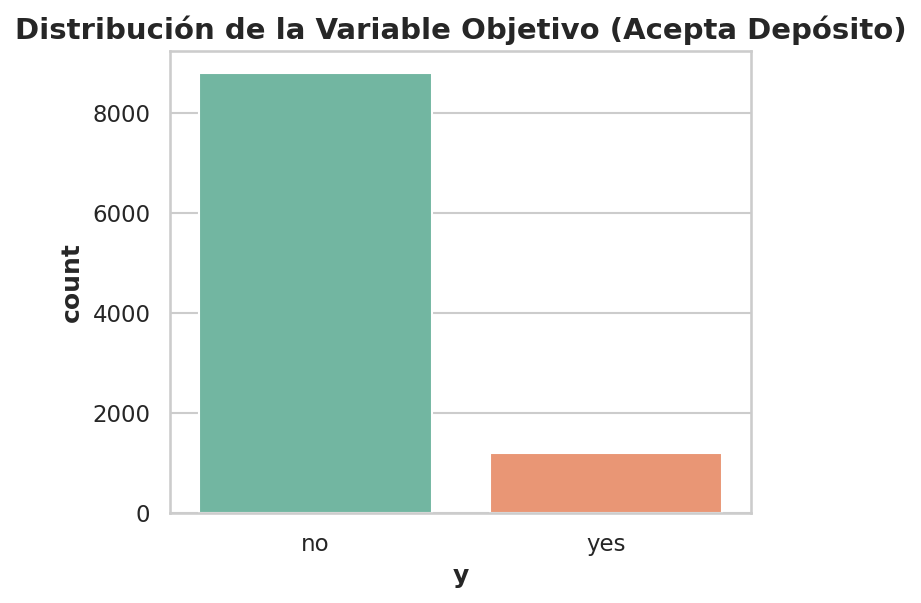

Tasa de conversión real: 12.06%


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report
from sklearn.semi_supervised import SelfTrainingClassifier

# Carga de datos reales
dataset_path = "datasets/bkm/bank-full.csv"
df_full = load_dataset(dataset_path)

# Para mantener la narrativa del caso de estudio, tomamos una muestra representativa de 10.000 clientes
df = df_full.sample(n=10000, random_state=42).reset_index(drop=True)

# Breve EDA: El Desbalance
plt.figure(figsize=(5, 4))
sns.countplot(x=df['y'], palette='Set2', hue=df['y'], legend=False)
plt.title("Distribución de la Variable Objetivo (Acepta Depósito)")
plt.show()

print(f"Tasa de conversión real: {(sum(df['y'] == 'yes') / len(df)) * 100:.2f}%")

Como vemos, es un *dataset* fuertemente desbalanceado (`~12%` de conversión). Si elegimos clientes al azar para llamar, 9 de cada 10 nos dirán que no.

### ⚠️ Criterio de Ingeniería: Prevención de Data Leakage



Si leemos la documentación del dataset, la variable `duration` (duración del último contacto en segundos) es altamente predictiva. Si la duración es 0, el cliente no aceptó.
Sin embargo, **no podemos saber cuánto durará una llamada antes de hacerla**. Si usamos esta variable para predecir a quién llamar hoy, estaremos cometiendo una fuga de datos (*Data Leakage*) masiva. Debemos eliminarla.



In [4]:
# Eliminamos la variable 'duration' para evitar Data Leakage
df = df.drop(columns=['duration'])

# Convertimos el target a binario (1 = yes, 0 = no)
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Separamos Features y Target
X = df.drop(columns=['y'])
y = df['y']

# Identificamos columnas categóricas y numéricas
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

# Preprocesamiento: One-Hot Encoding para categóricas y StandardScaler para numéricas
# Algo muy rudimentario, la idea no es encontrar el mejor modelo sino COMPARAR estrategias
# Para ello, basta con un baseline
preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ])

X_processed = preprocesador.fit_transform(X)

# El Test Set (20%) es sagrado. Representa el mundo real futuro. NUNCA le ocultamos etiquetas,
# pero el modelo solo lo usa para evaluarse al final.
X_train, X_test, y_train_oraculo, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

# EL ORÁCULO: Convertimos las etiquetas de entrenamiento en un array de Numpy.
# El modelo no tiene acceso a 'y_train_oraculo' directamente.
y_train_oraculo = y_train_oraculo.values

print(f"Clientes disponibles en la base de datos (Train): {len(X_train)}")
print(f"Presupuesto disponible: $500 (500 llamadas)")

Clientes disponibles en la base de datos (Train): 8000
Presupuesto disponible: $500 (500 llamadas)



---



## 3. Estrategia 1: El Baseline (Muestreo Aleatorio)



El enfoque estándar de un ingeniero junior: *"Tengo `$500`. Elijo 500 clientes al azar de la base de datos, los llamo, anoto lo que me dicen y entreno un Random Forest" (porque Random Forest es el mejor modelo que puede existir...)*.



In [10]:
# 1. Gastamos los $500 eligiendo 500 índices al azar
np.random.seed(42)
indices_aleatorios = np.random.choice(len(X_train), size=500, replace=False)

# 2. Consultamos al Oráculo (Hacemos las llamadas)
X_baseline = X_train[indices_aleatorios]
y_baseline = y_train_oraculo[indices_aleatorios]

# 3. Entrenamos el modelo
modelo_baseline = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
modelo_baseline.fit(X_baseline, y_baseline)

# 4. Evaluamos el ROI (Retorno de Inversión) en el Test Set
y_pred_base = modelo_baseline.predict(X_test)
f1_base = f1_score(y_test, y_pred_base)

print(f"F1-Score Baseline (Gastando $500 al azar): {f1_base:.4f}")

F1-Score Baseline (Gastando $500 al azar): 0.0403



**⚠️ Alerta de Mala Práctica:**
Llamar a clientes al azar es ineficiente. El modelo aprenderá rápidamente a identificar a los clientes que *obviamente* dirán que no. Gastar `$1` en llamar a un cliente que el modelo ya sabe que dirá que no, es tirar dinero a la basura. Necesitamos enseñarle al modelo los casos difíciles (la frontera de decisión).

---

## 4. Estrategia 2: Aprendizaje Semi-Supervisado (SSL)


El enfoque de un ingeniero intermedio: *"Ya gasté los `$500` en 500 clientes al azar. Pero me quedan 7.500 clientes en la base de datos que no llamé. Usaré Self-Training para que el modelo intente adivinar qué harían esos 7.500 clientes y aprenda de su propia confianza"*.

In [11]:
# 1. Preparamos el dataset SSL
# Los 500 que llamamos tienen su etiqueta real. Los 7.500 restantes tienen etiqueta -1.
y_train_ssl = np.full(len(X_train), -1)
y_train_ssl[indices_aleatorios] = y_train_oraculo[indices_aleatorios]

# 2. Instanciamos Self-Training
modelo_ssl = SelfTrainingClassifier(
    estimator=RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    threshold=0.99, # Confianza alta para evitar sesgo de confirmación
    max_iter=4
)

# 3. Entrenamos (El modelo usa los 500 reales + la topología de los 7.500 grises)
modelo_ssl.fit(X_train, y_train_ssl)

# 4. Evaluamos
y_pred_ssl = modelo_ssl.predict(X_test)
f1_ssl = f1_score(y_test, y_pred_ssl)

print(f"F1-Score SSL (Gastando $500 al azar + 7.500 datos gratis): {f1_ssl:.4f}")

F1-Score SSL (Gastando $500 al azar + 7.500 datos gratis): 0.0245


*Epeoró el resultado...* hacen falta grandes habilidades para configurar adecuadamente esto. Probamos otra estrategia.

### Estrategia 2b: Aprendizaje Semi-Supervisado con Label Spreading

Dado que el `SelfTrainingClassifier` no produjo los resultados esperados, probamos otra técnica de SSL: `LabelSpreading`. Esta técnica propaga las etiquetas conocidas a los datos no etiquetados basándose en un grafo de similitud entre las muestras.

In [12]:
from sklearn.semi_supervised import LabelSpreading

# El dataset SSL ya está preparado de la sección anterior:
# y_train_ssl tiene las 500 etiquetas reales y -1 para las 7.500 no etiquetadas.

# 1. Instanciamos LabelSpreading
# Usamos 'knn' para kernel para una base de datos grande como esta
# alpha es el parámetro de regularización, controla la influencia de las etiquetas originales.
modelo_label_spreading = LabelSpreading(kernel='knn', n_neighbors=7, alpha=0.2, max_iter=30)

# 2. Entrenamos (El modelo aprende de los 500 reales y propaga a los 7.500 grises)
modelo_label_spreading.fit(X_train, y_train_ssl)

# 3. Evaluamos en el Test Set
y_pred_ls = modelo_label_spreading.predict(X_test)
f1_ls = f1_score(y_test, y_pred_ls)

print(f"F1-Score Label Spreading (Gastando $500 al azar + 7.500 datos gratis): {f1_ls:.4f}")

F1-Score Label Spreading (Gastando $500 al azar + 7.500 datos gratis): 0.1016



El SSL nos da un pequeño empujón "gratis" sobre el Baseline. Pero seguimos arrastrando "*el pecado original*": los 500 clientes iniciales fueron elegidos a ciegas.

---

## 5. Estrategia 3: Active Learning (Cambio de Paradigma)


El enfoque de un Ingeniero Senior: *"No voy a gastar los `$500` de golpe. Voy a gastar `$50` para arrancar. Entreno un modelo básico. Luego, le pregunto al modelo: **¿Con qué clientes de la base de datos estás más confundido?** Gasto mis siguientes `$50` en llamar exclusivamente a esos clientes difíciles. Repito el ciclo hasta agotar el presupuesto"*.

> A esto se le llama **Uncertainty Sampling** (Muestreo por Incertidumbre).



### Programando el Bucle de Active Learning desde Cero


Para entender esto, no usamos librerías externas (tampoco hace falta). Calculamos la "confusión" del modelo matemáticamente. En clasificación binaria, un modelo está máximamente confundido cuando su probabilidad de predecir "Sí" es exactamente **0,50** (50%).



In [13]:
# 1. Inicialización: Gastamos los primeros $50 al azar para tener un punto de partida
presupuesto_total = 500
costo_por_iteracion = 50

np.random.seed(42)
indices_etiquetados = list(np.random.choice(len(X_train), size=costo_por_iteracion, replace=False))
indices_no_etiquetados =[i for i in range(len(X_train)) if i not in indices_etiquetados]

# Listas para guardar la evolución del aprendizaje
historial_presupuesto_al = [costo_por_iteracion]
historial_f1_al =[]

modelo_al = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

print("--- Iniciando Bucle de Active Learning ---")

# 2. El Bucle (Human-in-the-loop)
while len(indices_etiquetados) <= presupuesto_total:

    # A. Entrenamos el modelo con los datos que tenemos hasta ahora
    X_actual = X_train[indices_etiquetados]
    y_actual = y_train_oraculo[indices_etiquetados]
    modelo_al.fit(X_actual, y_actual)

    # B. Evaluamos y guardamos el rendimiento actual
    f1_actual = f1_score(y_test, modelo_al.predict(X_test))
    historial_f1_al.append(f1_actual)

    print(f"Presupuesto gastado: ${len(indices_etiquetados)} | F1-Score: {f1_actual:.4f}")

    # Condición de salida si agotamos los $500
    if len(indices_etiquetados) == presupuesto_total:
        break

    # C. LA MAGIA: Predecimos probabilidades sobre los clientes que AÚN NO HEMOS LLAMADO
    X_pool = X_train[indices_no_etiquetados]
    probabilidades = modelo_al.predict_proba(X_pool)

    # D. Calculamos la Incertidumbre (Qué tan cerca está la probabilidad máxima de 0.5)
    # Si prob=[0.51, 0.49], la max es 0.51 (Incertidumbre altísima)
    # Si prob=[0.99, 0.01], la max es 0.99 (Incertidumbre bajísima)
    incertidumbre = 1 - np.max(probabilidades, axis=1)

    # E. Seleccionamos los 50 clientes que más confunden al modelo
    # argsort ordena de menor a mayor. Tomamos los últimos 50 (mayor incertidumbre)
    indices_mas_confusos_relativos = np.argsort(incertidumbre)[-costo_por_iteracion:]

    # Mapeamos los índices relativos del pool a los índices absolutos originales
    indices_a_llamar =[indices_no_etiquetados[i] for i in indices_mas_confusos_relativos]

    # F. Actualizamos las listas (El Oráculo "hace las llamadas")
    indices_etiquetados.extend(indices_a_llamar)
    indices_no_etiquetados =[i for i in indices_no_etiquetados if i not in indices_a_llamar]

    historial_presupuesto_al.append(len(indices_etiquetados))

print("--- Bucle Finalizado ---")

--- Iniciando Bucle de Active Learning ---
Presupuesto gastado: $50 | F1-Score: 0.0000
Presupuesto gastado: $100 | F1-Score: 0.0000
Presupuesto gastado: $150 | F1-Score: 0.0315
Presupuesto gastado: $200 | F1-Score: 0.0398
Presupuesto gastado: $250 | F1-Score: 0.0772
Presupuesto gastado: $300 | F1-Score: 0.1069
Presupuesto gastado: $350 | F1-Score: 0.1844
Presupuesto gastado: $400 | F1-Score: 0.2583
Presupuesto gastado: $450 | F1-Score: 0.2671
Presupuesto gastado: $500 | F1-Score: 0.2848
--- Bucle Finalizado ---


## 6. Resultados y Discusión de Negocio (Curvas de Aprendizaje)



Para demostrar el valor de nuestro trabajo al equipo directivo, no basta con mostrar un número final. Debemos mostrar la **Curva de Aprendizaje** (*Learning Curve*): cómo evoluciona la inteligencia del modelo por cada dólar invertido.

Vamos a generar rápidamente la curva de aprendizaje para el Muestreo Aleatorio (Baseline) para poder compararla.



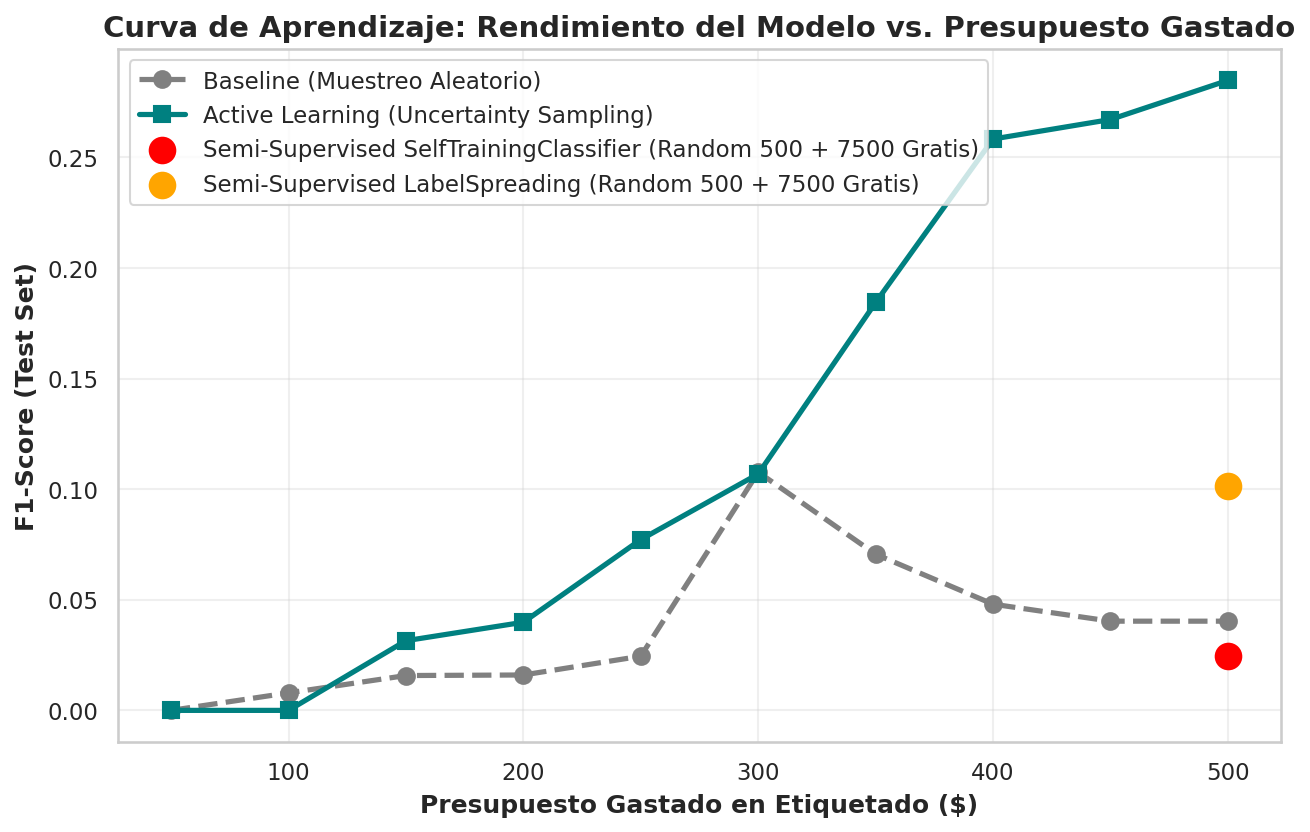

In [14]:
# Generamos la curva del Baseline (Muestreo Aleatorio) para los mismos puntos de presupuesto
historial_f1_random =[]

for presupuesto in historial_presupuesto_al:
    np.random.seed(42)
    idx_rnd = np.random.choice(len(X_train), size=presupuesto, replace=False)
    modelo_rnd = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    modelo_rnd.fit(X_train[idx_rnd], y_train_oraculo[idx_rnd])
    historial_f1_random.append(f1_score(y_test, modelo_rnd.predict(X_test)))

# Visualización: El ROI del Etiquetado
plt.figure(figsize=(10, 6))

# Curva Baseline
plt.plot(historial_presupuesto_al, historial_f1_random, marker='o', color='gray', linestyle='--', label='Baseline (Muestreo Aleatorio)')

# Curva Active Learning
plt.plot(historial_presupuesto_al, historial_f1_al, marker='s', color='teal', linewidth=2.5, label='Active Learning (Uncertainty Sampling)')

# Punto SSL
plt.scatter([500], [f1_ssl], color='red', s=150, zorder=5, label='Semi-Supervised SelfTrainingClassifier (Random 500 + 7500 Gratis)')
plt.scatter([500], [f1_ls], color='orange', s=150, zorder=5, label='Semi-Supervised LabelSpreading (Random 500 + 7500 Gratis)')


plt.title("Curva de Aprendizaje: Rendimiento del Modelo vs. Presupuesto Gastado", fontsize=14)
plt.xlabel("Presupuesto Gastado en Etiquetado ($)")
plt.ylabel("F1-Score (Test Set)")
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.show()

### Análisis de MLOps: Leyendo el Gráfico como Experto


Observar el gráfico superior. Es una clase magistral de gestión de recursos en Inteligencia Artificial:

1. **El Despegue del Active Learning (Línea Verde):**
   Observar cómo la línea verde sube drásticamente en las primeras iteraciones. Al obligar al modelo a estudiar los "casos límite" (clientes que están justo en la frontera entre aceptar o rechazar el depósito), el modelo define su frontera de decisión rapidísimo.
2. **El Estancamiento del Muestreo Aleatorio (Línea Gris):**
   La línea gris sube muy lento (puede tener algún pico incluso, pero es esporádico). Gastar `$500` al azar apenas logra el mismo rendimiento que *Active Learning* logró gastando solo `$200`. El muestreo aleatorio desperdicia llamadas en clientes obvios.
3. **El Papel del SSL (Punto Rojo y Naranja):**
   El Aprendizaje Semi-Supervisado mejoró el Baseline en el punto de los $500. Es útil, pero **no puede competir con una estrategia de recolección de datos inteligente**. En este caso, solamente una de las técnicas logró mejoras (*Label Spreading*), la otra no llegó al baseline.

**Conclusión de Negocio:**
Si hubiéramos usado *Active Learning*, podríamos haber detenido el proyecto al gastar **`$300`**, obteniendo un modelo superior al que el equipo de marketing habría obtenido gastando **`$500`** a ciegas. Ahorramos un 40% del presupuesto de la empresa.

## 7. Conclusiones y Siguientes Pasos


Este caso de estudio demuestra que en el Machine Learning moderno, **los datos son más importantes que el algoritmo**.

- **Usar Muestreo Aleatorio** solo cuando etiquetar datos sea absolutamente gratis y automático.
- **Usar Semi-Supervised Learning (SSL)** cuando ya te existe un dataset donde una pequeña parte fue etiquetada al azar en el pasado, y se quiere exprimir la topología de los datos restantes sin gastar más dinero.
- **Usar Active Learning** siempre que se esté diseñando un sistema desde cero donde un humano (*Human-in-the-loop*) deba intervenir para validar, clasificar o llamar por teléfono.

Con este conocimiento, no solo se sabe cómo entrenar modelos, sino cómo **orquestar el ciclo de vida completo de los datos (MLOps)**.

## Referencias


1. Moro, S., Laureano, R., & Cortez, P. (2011). *Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM Methodology*.
2. Settles, B. (2009). *Active learning literature survey*. University of Wisconsin-Madison Department of Computer Sciences.

---


## Entorno de Ejecución


In [15]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
